In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_2717040/1364232680.py:85: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_2717040/1364232680.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


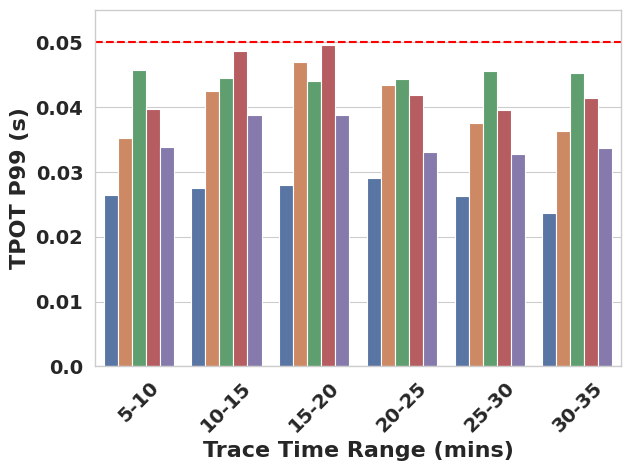

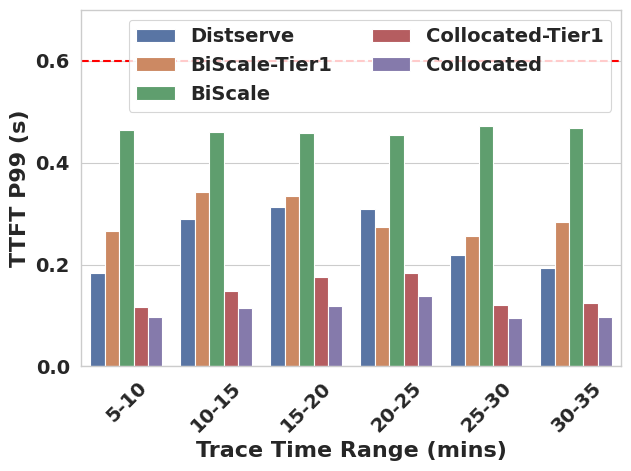

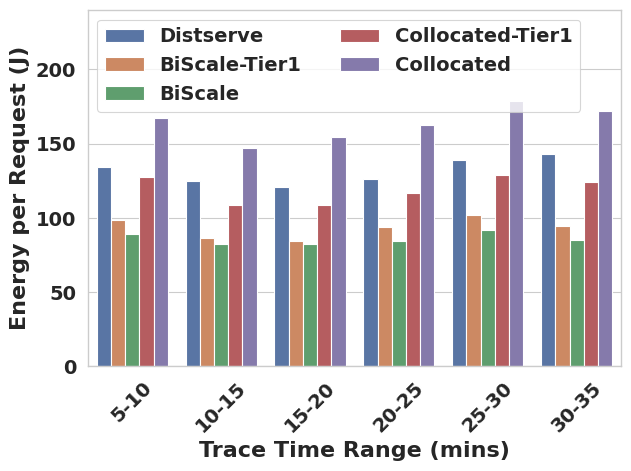

In [14]:
path_disag = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_0_Aug22_4nodes/disag/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_0_Aug22_4nodes/chunked/metrics.csv"
df_results_coll = pd.read_csv(path_coll)

df_results = pd.concat([df_results_disag, df_results_coll], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_6': 'Distserve 6',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_5': 'Distserve 5',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_4': 'Distserve 4',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_3': 'Distserve 3',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_2': 'Distserve 2',
    'DISTSERVE_AUG21_32GPU_AZURE_SHAREGPT_P67_1': 'Distserve 1',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_6': 'BiScale-Tier1 6',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_5': 'BiScale-Tier1 5',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_4': 'BiScale-Tier1 4',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_3': 'BiScale-Tier1 3',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_2': 'BiScale-Tier1 2',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_1': 'BiScale-Tier1 1',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_6_DVFS': 'BiScale 6',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_5_DVFS': 'BiScale 5',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_4_DVFS': 'BiScale 4',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_3_DVFS': 'BiScale 3',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_2_DVFS': 'BiScale 2',
    'OURS_AUG21_32GPU_AZURE_SHAREGPT_P67_1_DVFS': 'BiScale 1',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_6': 'Collocated-Tier1 6',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_5': 'Collocated-Tier1 5',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_4': 'Collocated-Tier1 4',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_3': 'Collocated-Tier1 3',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_2': 'Collocated-Tier1 2',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_1': 'Collocated-Tier1 1',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_6_DVFS': 'Collocated 6',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_5_DVFS': 'Collocated 5',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_4_DVFS': 'Collocated 4',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_3_DVFS': 'Collocated 3',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_2_DVFS': 'Collocated 2',
    'OURS_CHUNK_AUG21_32GPU_AZURE_SHAREGPT_P67_1_DVFS': 'Collocated 1'

}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)

df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.055)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04, 0.05])
ax.set_yticklabels(['0.0', '0.01', '0.02', '0.03', '0.04', '0.05'], fontsize=14, fontweight='bold')
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/real_67p_trace_tpot_w_coll.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.7)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})

plt.tight_layout()
plt.savefig("figs/real_67p_trace_ttft_w_coll_w_coll.pdf", format="pdf")

############################ energy per request - total #######################

df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 240)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
# ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_total_w_coll.pdf", format="pdf")



P99 Power (W) by System:
name
BiScale       12825.02762
Collocated    20706.63700
Distserve     16648.76700
Name: power_w, dtype: float64


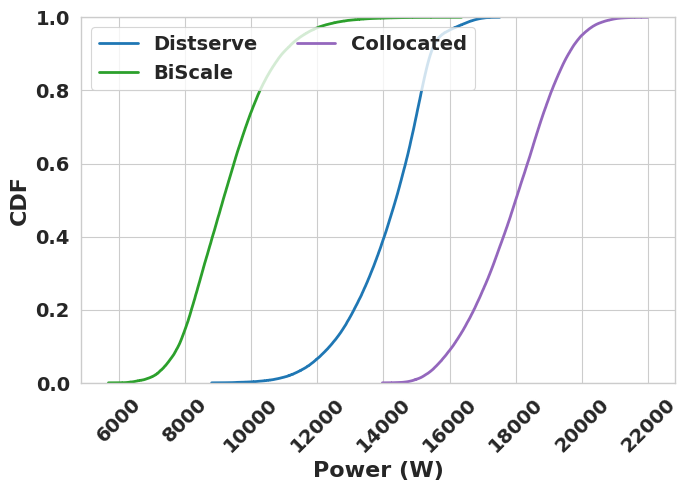

In [15]:
############################ power cdf #######################

from pathlib import Path
import numpy as np
from matplotlib.lines import Line2D


power_source_specs = [
    (
        Path(path_disag).parent,
        df_results_disag,
    ),
    (
        Path(path_coll).parent,
        df_results_coll,
    )
]

def load_run_power_series(run_root: Path) -> pd.DataFrame:
    total_power_path = run_root / "total_power.csv"
    if total_power_path.exists():
        power_df = pd.read_csv(total_power_path)
        if not power_df.empty and "power_w" in power_df.columns:
            return power_df[["power_w"]].copy()
        return pd.DataFrame(columns=["power_w"])

    power_log_path = run_root / "power_log.csv"
    if not power_log_path.exists():
        return pd.DataFrame(columns=["power_w"])

    raw_power_df = pd.read_csv(power_log_path)
    power_cols = [
        col for col in raw_power_df.columns
        if col.startswith("GPU_") and col.endswith("_power_w")
    ]
    if not power_cols:
        return pd.DataFrame(columns=["power_w"])

    power_df = raw_power_df[power_cols].sum(axis=1).to_frame(name="power_w")
    return power_df

power_rows = []
for root_dir, metrics_df in power_source_specs:
    source_df = metrics_df[metrics_df["instance"] == "total"].copy()
    source_df["run_dir_name"] = source_df["expr_dir"]
    source_df["expr_dir"] = source_df["expr_dir"].replace(rename_mapping)
    source_df = source_df[source_df["expr_dir"].isin(rename_mapping.values())]
    source_df["name"] = source_df["expr_dir"].str.replace(r"\s+\d+$", "", regex=True)
    source_df["name"] = pd.Categorical(
        source_df["name"],
        categories=["Distserve", "BiScale", "Collocated"],
        ordered=True,
    )

    for _, row in source_df.iterrows():
        power_df = load_run_power_series(root_dir / row["run_dir_name"])
        if power_df.empty:
            continue
        power_df = power_df[["power_w"]].copy()
        power_df["name"] = row["name"]
        power_rows.append(power_df)

power_cdf_df = pd.concat(power_rows, ignore_index=True)
power_cdf_df = power_cdf_df.dropna(subset=["power_w", "name"])

palette = {
    "Distserve": "#1f77b4",
    "BiScale": "#2ca02c",
    "Collocated": "#9467bd",
}

sns.set_theme(context="paper", style="whitegrid")
plt.figure(figsize=(7, 5))
ax = sns.ecdfplot(
    data=power_cdf_df,
    x="power_w",
    hue="name",
    hue_order=["Distserve", "BiScale", "Collocated"],
    palette=palette,
    linewidth=2,
)

ax.set_xlabel("Power (W)", fontsize=16, fontweight="bold")
ax.set_ylabel("CDF", fontsize=16, fontweight="bold")
ax.tick_params(axis="both", labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
    label.set_rotation(45)
    label.set_ha('center')
for label in ax.get_yticklabels():
    label.set_fontweight("bold")
legend_handles = [
    Line2D([0], [0], color=palette[name], lw=2, label=name)
    for name in ["Distserve", "BiScale", "Collocated"]
]
ax.legend(handles=legend_handles, title="", ncol=2, prop={"size": 14, "weight": "bold"})
plt.tight_layout()
plt.savefig("figs/real_67p_trace_power_cdf_disag_vs_coll.pdf", format="pdf")

print("\nP99 Power (W) by System:")
print(power_cdf_df.groupby("name")["power_w"].quantile(0.99))


In [16]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_BT1'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_CT1'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Collocated-Tier1')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)

summary_rows = []
for name in ["Distserve", "BiScale-Tier1", "BiScale"]:
    grp = df_results[df_results["name"] == name]
    row = grp.mean(numeric_only=True).to_dict()
    row["expr_dir"] = f"{name} avg"
    row["instance"] = "total"
    row["name"] = name
    row["rps"] = "avg"
    summary_rows.append(row)
df_results = pd.concat([df_results, pd.DataFrame(summary_rows)], ignore_index=True)
df_results[['expr_dir', 'energy_per_req', 'energy_norm_D', 'energy_norm_BT1', 'energy_norm_CT1']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_req,energy_norm_D,energy_norm_BT1,energy_norm_CT1
30,Distserve avg,131.217875,0.000000,-40.424566,-10.502527
25,Distserve 6,143.151709,0.000000,-51.435950,-15.580916
20,Distserve 5,138.620755,0.000000,-36.463731,-7.678067
15,Distserve 4,125.950838,0.000000,-33.785900,-8.155949
10,Distserve 3,120.485273,0.000000,-41.230479,-11.033262
5,Distserve 2,124.869843,0.000000,-43.740979,-15.265253
0,Distserve 1,134.228833,0.000000,-35.890355,-5.301713
28,Collocated-Tier1 6,123.854105,12.045083,-33.195365,0.000000
23,Collocated-Tier1 5,128.736296,4.828194,-29.874998,0.000000
18,Collocated-Tier1 4,116.452991,5.060479,-27.015692,0.000000
